# Linear Regression from Scratch 📈

Welcome to the first notebook in the **ML-Under-The-Hood** series! Today, we are building **Linear Regression** from the ground up using only `numpy`.

## 📖 Theoretical Background

Linear regression is a statistical method for modeling the relationship between a dependent variable $y$ and one or more independent variables $X$. 

### 1. The Hypothesis
The linear model predicts $y$ as a weighted sum of the input features:
$$\hat{y} = Xw + b$$
Where:
- $X$ is the input data matrix.
- $w$ is the weight vector.
- $b$ is the bias (intercept) term.
- $\hat{y}$ is the predicted value.

### 2. The Cost Function (Mean Squared Error)
To measure how well our model is performing, we use the **Mean Squared Error (MSE)** loss function:
$$J(w, b) = \frac{1}{2m} \sum_{i=1}^{m} (\hat{y}^{(i)} - y^{(i)})^2$$
Where $m$ is the number of training examples.

### 3. Optimization: Gradient Descent
To find the optimal weights that minimize the cost, we update them iteratively in the opposite direction of the gradient:
$$w = w - \alpha \frac{\partial J}{\partial w}$$
$$b = b - \alpha \frac{\partial J}{\partial b}$$

The gradients are:
$$\frac{\partial J}{\partial w} = \frac{1}{m} X^T(\hat{y} - y)$$
$$\frac{\partial J}{\partial b} = \frac{1}{m} \sum(\hat{y} - y)$$

### 4. The Normal Equation
For smaller datasets, we can also solve for the optimal weights analytically using the **Normal Equation**:
$$w = (X^T X)^{-1} X^T y$$

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression

# Set seed for reproducibility
np.random.seed(42)

## 🏗️ The Implementation

We will implement our `LinearRegression` class with two methods of optimization: `gradient_descent` and `normal_equation`.

In [2]:
class LinearRegression:
    def __init__(self, learning_rate=0.01, n_iterations=1000, method='gradient_descent'):
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.method = method
        self.weights = None
        self.bias = None
        self.loss_history = []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        
        if self.method == 'normal_equation':
            # Add bias term (1s) to X
            X_b = np.c_[np.ones((n_samples, 1)), X]
            # theta = (X^T X)^-1 X^T y
            theta = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y
            self.bias = theta[0]
            self.weights = theta[1:]
            
        else: # Gradient Descent
            # Initialize parameters
            self.weights = np.zeros(n_features)
            self.bias = 0

            for _ in range(self.n_iterations):
                # 1. Prediction
                y_predicted = np.dot(X, self.weights) + self.bias

                # 2. Compute Loss (MSE)
                loss = (1 / (2 * n_samples)) * np.sum((y_predicted - y) ** 2)
                self.loss_history.append(loss)

                # 3. Compute Gradients
                dw = (1 / n_samples) * np.dot(X.T, (y_predicted - y))
                db = (1 / n_samples) * np.sum(y_predicted - y)

                # 4. Update Parameters
                self.weights -= self.lr * dw
                self.bias -= self.lr * db

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias

## 🧪 Data Generation and Training

Let's create a simple dataset and train our model.

In [3]:
# Generate toy data
X, y = make_regression(n_samples=100, n_features=1, noise=20, random_state=42)
X_train = X
y_train = y

# 1. Train with Gradient Descent
model_gd = LinearRegression(learning_rate=0.1, n_iterations=1000, method='gradient_descent')
model_gd.fit(X_train, y_train)

# 2. Train with Normal Equation
model_ne = LinearRegression(method='normal_equation')
model_ne.fit(X_train, y_train)

print(f"GD Weights: {model_gd.weights[0]:.4f}, Bias: {model_gd.bias:.4f}")
print(f"NE Weights: {model_ne.weights[0]:.4f}, Bias: {model_ne.bias:.4f}")

GD Weights: 47.1332, Bias: 2.3302
NE Weights: 47.1332, Bias: 2.3302


## 📊 Visualization

First, let's visualize the loss history for Gradient Descent.

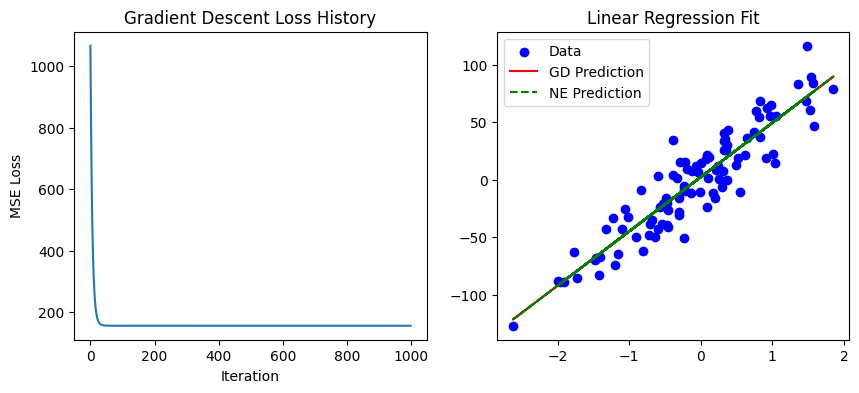

In [4]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(model_gd.loss_history)
plt.title("Gradient Descent Loss History")
plt.xlabel("Iteration")
plt.ylabel("MSE Loss")

plt.subplot(1, 2, 2)
plt.scatter(X, y, color="blue", label="Data")
plt.plot(X, model_gd.predict(X), color="red", label="GD Prediction")
plt.plot(X, model_ne.predict(X), color="green", linestyle="--", label="NE Prediction")
plt.title("Linear Regression Fit")
plt.legend()
plt.show()

## 📊 Additional Visualizations

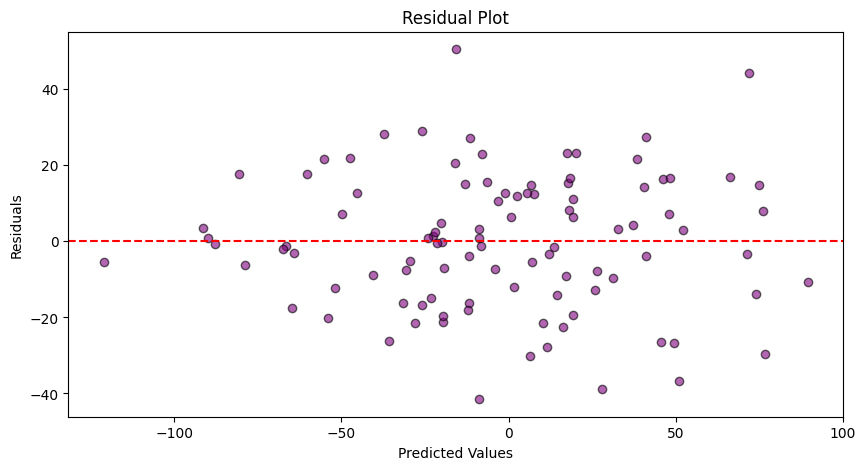

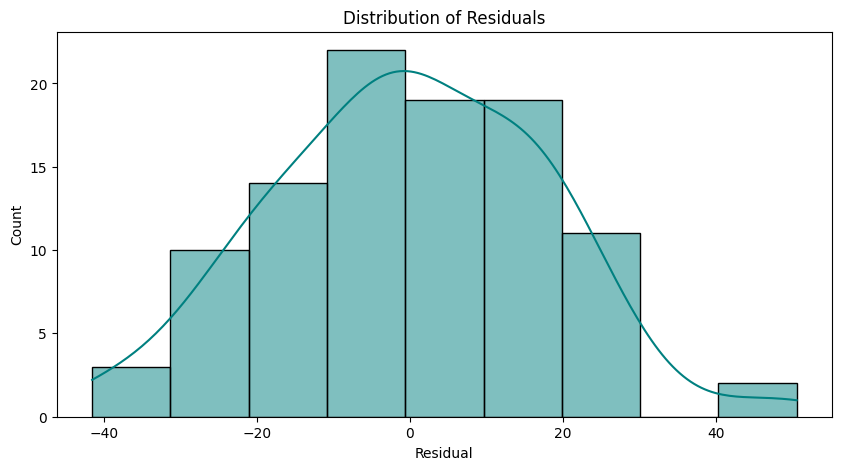

In [5]:

# 1. Residual Plot
y_pred = model_gd.predict(X)
residuals = y - y_pred

plt.figure(figsize=(10, 5))
plt.scatter(y_pred, residuals, color='purple', alpha=0.6, edgecolors='k')
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residual Plot')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.show()

# 2. Distribution of Residuals
import seaborn as sns
plt.figure(figsize=(10, 5))
sns.histplot(residuals, kde=True, color='teal')
plt.title('Distribution of Residuals')
plt.xlabel('Residual')
plt.show()


## 🏠 Multiple Linear Regression

Now let's extend our model to handle multiple features. Multiple Linear Regression models the relationship between two or more explanatory variables and a response variable.

In [ ]:
# Generate data with 2 features
X_multi, y_multi = make_regression(n_samples=100, n_features=2, noise=15, random_state=42)

# Train the model
model_multi = LinearRegression(learning_rate=0.1, n_iterations=1000)
model_multi.fit(X_multi, y_multi)

print(f"Weights: {model_multi.weights}")
print(f"Bias: {model_multi.bias:.4f}")

In [ ]:
# Actual vs Predicted Plot
y_pred_multi = model_multi.predict(X_multi)

plt.figure(figsize=(8, 6))
plt.scatter(y_multi, y_pred_multi, color='blue', alpha=0.6)
plt.plot([y_multi.min(), y_multi.max()], [y_multi.min(), y_multi.max()], 'r--', lw=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Multiple Linear Regression: Actual vs Predicted')
plt.show()

In [ ]:
# 3D Visualization for 2 Features
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_multi[:, 0], X_multi[:, 1], y_multi, color='blue', label='Actual Data')

# Create a meshgrid for the regression plane
x1_range = np.linspace(X_multi[:, 0].min(), X_multi[:, 0].max(), 10)
x2_range = np.linspace(X_multi[:, 1].min(), X_multi[:, 1].max(), 10)
X1_mesh, X2_mesh = np.meshgrid(x1_range, x2_range)
Y_mesh = model_multi.weights[0] * X1_mesh + model_multi.weights[1] * X2_mesh + model_multi.bias

ax.plot_surface(X1_mesh, X2_mesh, Y_mesh, color='red', alpha=0.3)

ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_zlabel('Target')
ax.set_title('Multiple Linear Regression (2 Features)')
plt.show()